# Statistical Analysis of Model vs Normal Eviction Policy
## OpenFiles Workload

This notebook analyzes paired traces from model-based and normal eviction policies,
calculating hit ratios and testing for statistical significance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import re
from typing import Tuple, List

plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

## 1. Data Loading and Pairing

In [2]:
def count_rows_in_csv(filepath: Path) -> int:
    """Count number of rows in CSV (excluding header)"""
    with open(filepath, 'r') as f:
        return sum(1 for _ in f) - 1

def extract_timestamp(filename: str) -> str:
    """Extract timestamp from filename like cache_access_20260219_082228_access.csv"""
    match = re.search(r'(\d{8}_\d{6})', filename)
    return match.group(1) if match else None

def load_paired_data(model_dir: Path, normal_dir: Path) -> pd.DataFrame:
    """
    Load and pair model and normal run data by sorted order (index).
    For each run, match access and insertion files by timestamp to calculate hit ratios.
    Hit ratio = (accesses - insertions) / accesses
    Returns DataFrame with paired observations.
    """
    model_access_files = sorted(model_dir.glob('*_access.csv'))
    model_insertion_files = sorted(model_dir.glob('*_insertion.csv'))
    normal_access_files = sorted(normal_dir.glob('*_access.csv'))
    normal_insertion_files = sorted(normal_dir.glob('*_insertion.csv'))
    
    print(f"Found {len(model_access_files)} model access files")
    print(f"Found {len(model_insertion_files)} model insertion files")
    print(f"Found {len(normal_access_files)} normal access files")
    print(f"Found {len(normal_insertion_files)} normal insertion files")
    
    model_access_dict = {extract_timestamp(f.name): f for f in model_access_files}
    model_insertion_dict = {extract_timestamp(f.name): f for f in model_insertion_files}
    normal_access_dict = {extract_timestamp(f.name): f for f in normal_access_files}
    normal_insertion_dict = {extract_timestamp(f.name): f for f in normal_insertion_files}
    
    n_pairs = min(len(model_access_files), len(normal_access_files))
    print(f"\nCreating {n_pairs} paired observations...")
    
    data = []
    for i in range(n_pairs):
        model_access_file = model_access_files[i]
        normal_access_file = normal_access_files[i]
        
        model_ts = extract_timestamp(model_access_file.name)
        normal_ts = extract_timestamp(normal_access_file.name)
        
        model_accesses = count_rows_in_csv(model_access_file)
        normal_accesses = count_rows_in_csv(normal_access_file)
        
        model_insertions = 0
        normal_insertions = 0
        
        if model_ts in model_insertion_dict:
            model_insertions = count_rows_in_csv(model_insertion_dict[model_ts])
        
        if normal_ts in normal_insertion_dict:
            normal_insertions = count_rows_in_csv(normal_insertion_dict[normal_ts])
        
        model_hit_ratio = (model_accesses - model_insertions) / model_accesses if model_accesses > 0 else 0
        normal_hit_ratio = (normal_accesses - normal_insertions) / normal_accesses if normal_accesses > 0 else 0
        
        data.append({
            'pair_index': i,
            'model_timestamp': model_ts,
            'normal_timestamp': normal_ts,
            'model_accesses': model_accesses,
            'model_insertions': model_insertions,
            'model_hit_ratio': model_hit_ratio,
            'normal_accesses': normal_accesses,
            'normal_insertions': normal_insertions,
            'normal_hit_ratio': normal_hit_ratio
        })
    
    return pd.DataFrame(data)

In [3]:
# Load the paired data
model_dir = Path('../data/model-eval/openfiles_model_run')
normal_dir = Path('../data/model-eval/openfiles_normal_run')

df = load_paired_data(model_dir, normal_dir)
print(f"\nLoaded {len(df)} paired observations")

Found 50 model access files
Found 50 model insertion files
Found 50 normal access files
Found 50 normal insertion files

Creating 50 paired observations...

Loaded 50 paired observations


## 2. Data Summary and Hit Ratios

In [4]:
from scipy import stats
from math import sqrt

print("\nModel Hit Ratio:")
model_stats = stats.describe(df['model_hit_ratio'])
print(model_stats)
print(f"mean: {model_stats.mean} stddev: {sqrt(model_stats.variance)})")

print("\nNormal Hit Ratio:")
normal_stats = stats.describe(df['normal_hit_ratio'])
print(normal_stats)
print(f"mean: {normal_stats.mean} stddev: {sqrt(normal_stats.variance)})")

mean_diff = df['model_hit_ratio'].mean() - df['normal_hit_ratio'].mean()
print(f"\nMean difference (Model - Normal): {mean_diff:.4f}")


Model Hit Ratio:
DescribeResult(nobs=np.int64(50), minmax=(np.float64(-2.0021299254526093), np.float64(-1.4523705959112658)), mean=np.float64(-1.6314854644318464), variance=np.float64(0.01382974978066113), skewness=np.float64(-0.9180643142023123), kurtosis=np.float64(0.8785119396779821))
mean: -1.6314854644318464 stddev: 0.11759995655042195)

Normal Hit Ratio:
DescribeResult(nobs=np.int64(50), minmax=(np.float64(-1.8698315467075037), np.float64(-1.6051899907321594)), mean=np.float64(-1.712950152457892), variance=np.float64(0.006039125542779436), skewness=np.float64(-0.025731664102431762), kurtosis=np.float64(-1.4523962732533582))
mean: -1.712950152457892 stddev: 0.07771181083194134)

Mean difference (Model - Normal): 0.0815


## 3. Distribution Analysis

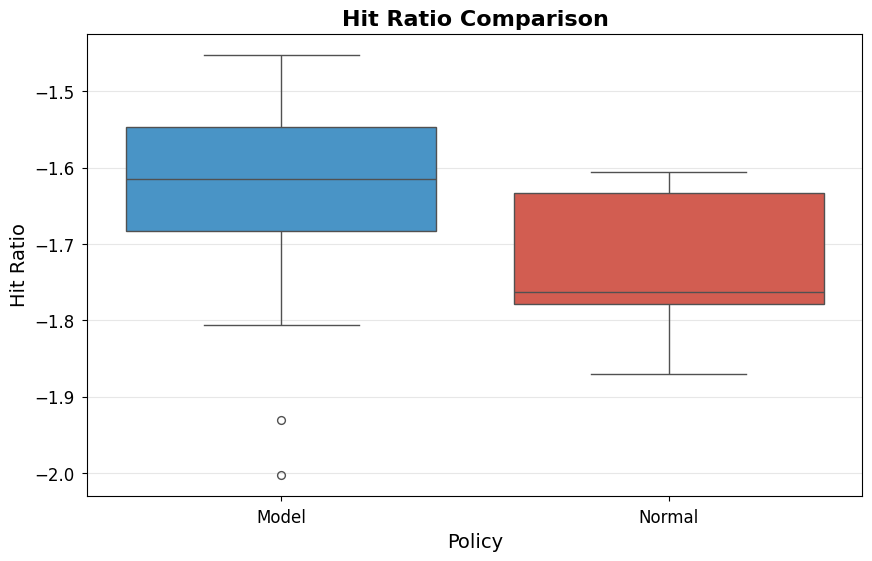

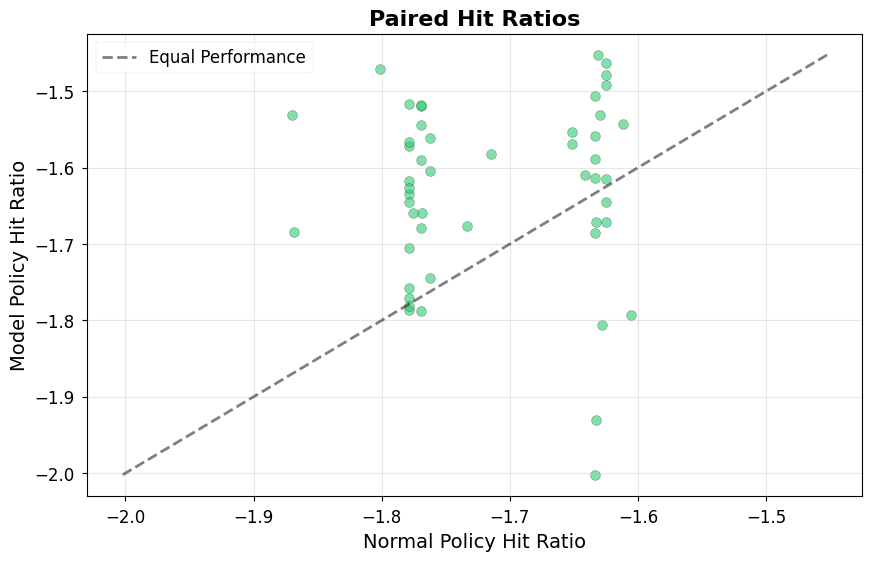

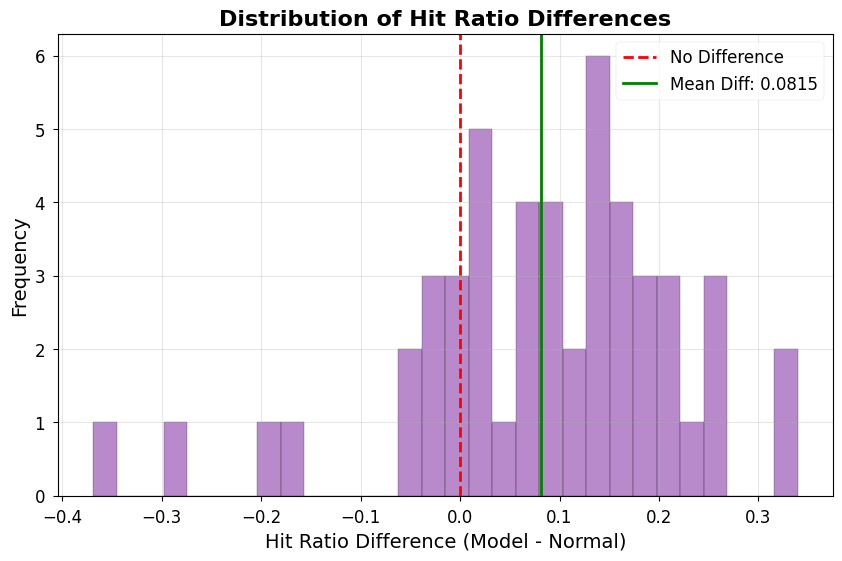

In [5]:
plt.figure(figsize=(10, 6))
hit_ratio_data = pd.DataFrame({
    'Hit Ratio': list(df['model_hit_ratio']) + list(df['normal_hit_ratio']),
    'Policy': ['Model'] * len(df) + ['Normal'] * len(df)
})
sns.boxplot(data=hit_ratio_data, x='Policy', y='Hit Ratio', hue='Policy', 
            palette=['#3498db', '#e74c3c'], legend=False)
plt.title('Hit Ratio Comparison', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df['normal_hit_ratio'], df['model_hit_ratio'], alpha=0.6, s=50, color='#2ecc71', edgecolor='black')
min_val = min(df['normal_hit_ratio'].min(), df['model_hit_ratio'].min())
max_val = max(df['normal_hit_ratio'].max(), df['model_hit_ratio'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=2, label='Equal Performance')
plt.xlabel('Normal Policy Hit Ratio')
plt.ylabel('Model Policy Hit Ratio')
plt.title('Paired Hit Ratios', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

df['hit_ratio_diff'] = df['model_hit_ratio'] - df['normal_hit_ratio']
plt.figure(figsize=(10, 6))
plt.hist(df['hit_ratio_diff'], bins=30, alpha=0.7, color='#9b59b6', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Difference')
plt.axvline(x=df['hit_ratio_diff'].mean(), color='green', linestyle='-', linewidth=2, 
                   label=f'Mean Diff: {df["hit_ratio_diff"].mean():.4f}')
plt.xlabel('Hit Ratio Difference (Model - Normal)')
plt.ylabel('Frequency')
plt.title('Distribution of Hit Ratio Differences', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Statistical Significance Testing

We'll use a paired t-test since we have matched pairs of observations (same workload run with different policies).

In [6]:
model_values = df['model_hit_ratio'].values
normal_values = df['normal_hit_ratio'].values
metric_name = 'Hit Ratio'
differences = df['hit_ratio_diff'].values

t_statistic, p_value = stats.ttest_rel(model_values, normal_values)

mean_diff = np.mean(differences)
std_diff = np.std(differences, ddof=1)
cohens_d = mean_diff / std_diff if std_diff > 0 else 0

n = len(differences)
se = std_diff / np.sqrt(n)
ci_95 = stats.t.interval(0.95, n-1, loc=mean_diff, scale=se)

print(f"\nWorkload: OpenFiles")
print(f"Number of paired observations: {n}")
print(f"\nMetric: {metric_name}")
print(f"\nModel Policy:")
print(f"  Mean: {np.mean(model_values):.6f}")
print(f"  Std:  {np.std(model_values, ddof=1):.6f}")
print(f"  Min:  {np.min(model_values):.6f}")
print(f"  Max:  {np.max(model_values):.6f}")
print(f"\nNormal Policy:")
print(f"  Mean: {np.mean(normal_values):.6f}")
print(f"  Std:  {np.std(normal_values, ddof=1):.6f}")
print(f"  Min:  {np.min(normal_values):.6f}")
print(f"  Max:  {np.max(normal_values):.6f}")
print(f"\nPaired Differences (Model - Normal):")
print(f"  Mean: {mean_diff:.6f}")
print(f"  Std:  {std_diff:.6f}")
print(f"  95% CI: [{ci_95[0]:.6f}, {ci_95[1]:.6f}]")
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_statistic:.6f}")
print(f"  p-value: {p_value:.6e}")
print(f"  Degrees of freedom: {n-1}")
print(f"\nEffect Size:")
print(f"  Cohen's d: {cohens_d:.6f}")

print(f"\n" + "="*70)
print("INTERPRETATION")
print("="*70)
alpha = 0.05
if p_value < alpha:
    print(f"\n✓ The difference is STATISTICALLY SIGNIFICANT (p < {alpha})")
    if mean_diff > 0:
        print(f"  → Model policy achieves {mean_diff:.4f} ({mean_diff*100:.2f}%) higher hit ratio on average")
        print(f"  → This represents a significant improvement in cache performance")
    else:
        print(f"  → Normal policy achieves {-mean_diff:.4f} ({-mean_diff*100:.2f}%) higher hit ratio on average")
        print(f"  → The model policy performs significantly worse")
else:
    print(f"\n✗ The difference is NOT statistically significant (p >= {alpha})")

print(f"\nEffect Size Interpretation (Cohen's d = {cohens_d:.4f}):")
abs_d = abs(cohens_d)
if abs_d < 0.2:
    print("  → Negligible effect")
elif abs_d < 0.5:
    print("  → Small effect")
elif abs_d < 0.8:
    print("  → Medium effect")
else:
    print("  → Large effect")

print("\n" + "="*70)


Workload: OpenFiles
Number of paired observations: 50

Metric: Hit Ratio

Model Policy:
  Mean: -1.631485
  Std:  0.117600
  Min:  -2.002130
  Max:  -1.452371

Normal Policy:
  Mean: -1.712950
  Std:  0.077712
  Min:  -1.869832
  Max:  -1.605190

Paired Differences (Model - Normal):
  Mean: 0.081465
  Std:  0.139706
  95% CI: [0.041761, 0.121169]

Paired t-test:
  t-statistic: 4.123235
  p-value: 1.439134e-04
  Degrees of freedom: 49

Effect Size:
  Cohen's d: 0.583114

INTERPRETATION

✓ The difference is STATISTICALLY SIGNIFICANT (p < 0.05)
  → Model policy achieves 0.0815 (8.15%) higher hit ratio on average
  → This represents a significant improvement in cache performance

Effect Size Interpretation (Cohen's d = 0.5831):
  → Medium effect



## 5. Additional Visualizations

==================== OpenFiles Workload: Model vs Normal Eviction Policy ====================



/var/folders/r8/yrxkgs1j3075p5j9jk04pk7w0000gn/T/ipykernel_45078/4244670419.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


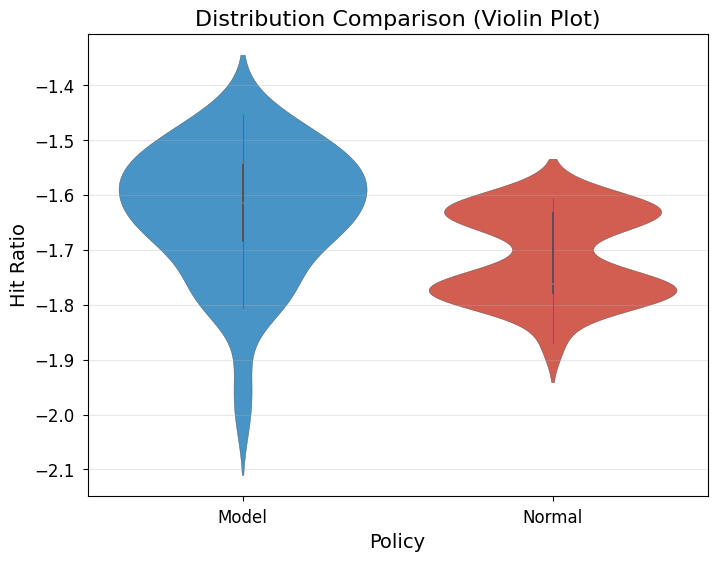

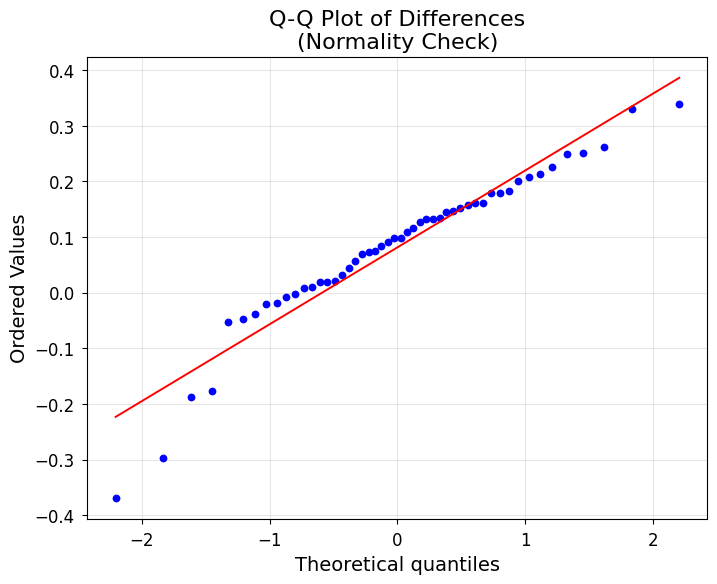

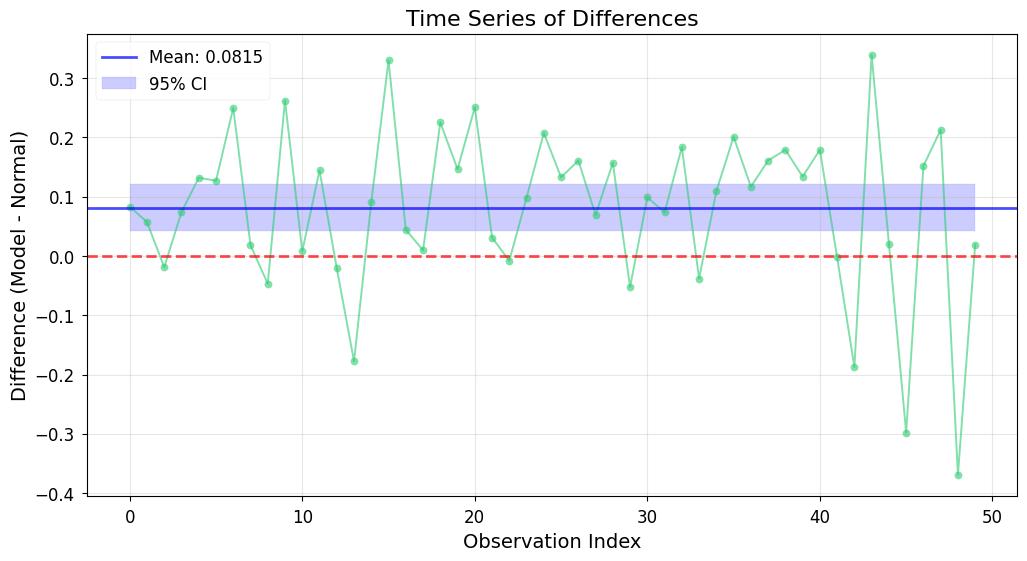

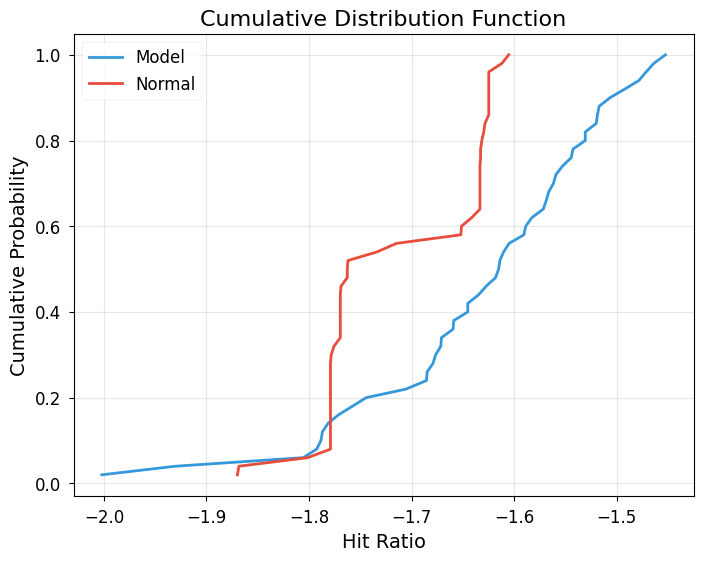

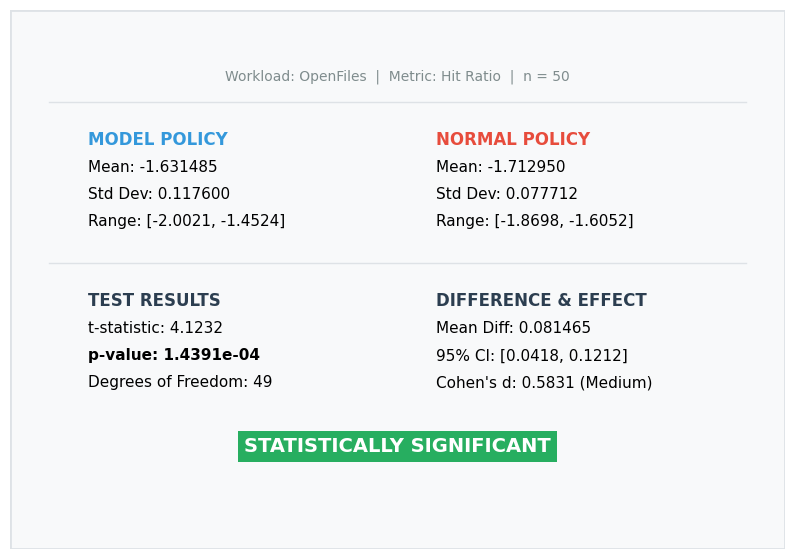

In [7]:
print(f"{'='*20} OpenFiles Workload: Model vs Normal Eviction Policy {'='*20}\n")

plt.figure(figsize=(8, 6))
data_for_violin = pd.DataFrame(
    {
        "Value": list(model_values) + list(normal_values),
        "Policy": ["Model"] * len(model_values) + ["Normal"] * len(normal_values),
    }
)
sns.violinplot(
    data=data_for_violin, x="Policy", y="Value", palette=["#3498db", "#e74c3c"]
)
plt.ylabel("Hit Ratio" if metric_name == "Hit Ratio" else "Access Count")
plt.title("Distribution Comparison (Violin Plot)")
plt.grid(True, alpha=0.3, axis="y")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(differences, dist="norm", plot=plt.gca())
plt.title("Q-Q Plot of Differences\n(Normality Check)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(
    range(len(differences)),
    differences,
    marker="o",
    linestyle="-",
    alpha=0.6,
    color="#2ecc71",
)
plt.axhline(y=0, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.axhline(
    y=mean_diff,
    color="blue",
    linestyle="-",
    linewidth=2,
    alpha=0.7,
    label=f"Mean: {mean_diff:.4f}",
)
plt.fill_between(
    range(len(differences)), ci_95[0], ci_95[1], alpha=0.2, color="blue", label="95% CI"
)
plt.xlabel("Observation Index")
plt.ylabel("Difference (Model - Normal)")
plt.title("Time Series of Differences")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
sorted_model = np.sort(model_values)
sorted_normal = np.sort(normal_values)
y = np.arange(1, len(sorted_model) + 1) / len(sorted_model)
plt.plot(sorted_model, y, label="Model", linewidth=2, color="#3498db")
plt.plot(sorted_normal, y, label="Normal", linewidth=2, color="#e74c3c")
plt.xlabel(metric_name)
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution Function")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

sig_color = "#27ae60" if p_value < 0.05 else "#c0392b"
sig_text = "STATISTICALLY SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
eff_size_text = (
    "Negligible"
    if abs(cohens_d) < 0.2
    else (
        "Small" if abs(cohens_d) < 0.5 else "Medium" if abs(cohens_d) < 0.8 else "Large"
    )
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.axis("off")

ax.add_patch(
    plt.Rectangle(
        (0, 0), 1, 1, fill=True, color="#f8f9fa", transform=ax.transAxes, zorder=0
    )
)
ax.add_patch(
    plt.Rectangle(
        (0, 0),
        1,
        1,
        fill=False,
        edgecolor="#dee2e6",
        linewidth=2,
        transform=ax.transAxes,
        zorder=1,
    )
)

plt.text(
    0.5,
    0.87,
    f"Workload: OpenFiles  |  Metric: {metric_name}  |  n = {n}",
    fontsize=10,
    ha="center",
    color="#7f8c8d",
)

plt.axhline(y=0.83, xmin=0.05, xmax=0.95, color="#dee2e6", linewidth=1)

col1, col2, y_start = 0.1, 0.55, 0.75

plt.text(col1, y_start, "MODEL POLICY", fontsize=12, fontweight="bold", color="#3498db")
plt.text(col1, y_start - 0.05, f"Mean: {np.mean(model_values):.6f}", fontsize=11)
plt.text(
    col1, y_start - 0.10, f"Std Dev: {np.std(model_values, ddof=1):.6f}", fontsize=11
)
plt.text(
    col1,
    y_start - 0.15,
    f"Range: [{np.min(model_values):.4f}, {np.max(model_values):.4f}]",
    fontsize=11,
)

plt.text(
    col2, y_start, "NORMAL POLICY", fontsize=12, fontweight="bold", color="#e74c3c"
)
plt.text(col2, y_start - 0.05, f"Mean: {np.mean(normal_values):.6f}", fontsize=11)
plt.text(
    col2, y_start - 0.10, f"Std Dev: {np.std(normal_values, ddof=1):.6f}", fontsize=11
)
plt.text(
    col2,
    y_start - 0.15,
    f"Range: [{np.min(normal_values):.4f}, {np.max(normal_values):.4f}]",
    fontsize=11,
)

plt.axhline(y=0.53, xmin=0.05, xmax=0.95, color="#dee2e6", linewidth=1)

plt.text(col1, 0.45, "TEST RESULTS", fontsize=12, fontweight="bold", color="#2c3e50")
plt.text(col1, 0.40, f"t-statistic: {t_statistic:.4f}", fontsize=11)
plt.text(
    col1,
    0.35,
    f"p-value: {p_value:.4e}",
    fontsize=11,
    fontweight="bold" if p_value < 0.05 else "normal",
)
plt.text(col1, 0.30, f"Degrees of Freedom: {n-1}", fontsize=11)

plt.text(
    col2, 0.45, "DIFFERENCE & EFFECT", fontsize=12, fontweight="bold", color="#2c3e50"
)
plt.text(col2, 0.40, f"Mean Diff: {mean_diff:.6f}", fontsize=11)
plt.text(col2, 0.35, f"95% CI: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]", fontsize=11)
plt.text(col2, 0.30, f"Cohen's d: {cohens_d:.4f} ({eff_size_text})", fontsize=11)

plt.text(
    0.5,
    0.18,
    sig_text,
    fontsize=14,
    fontweight="bold",
    ha="center",
    color="white",
    bbox=dict(facecolor=sig_color, edgecolor="none"),
)

plt.show()

## 6. Export Results

In [8]:
results_df = df.copy()
# save if we want

summary_stats = {
    'workload': 'openfiles',
    'n_observations': n,
    'metric': metric_name,
    'model_mean': np.mean(model_values),
    'model_std': np.std(model_values, ddof=1),
    'normal_mean': np.mean(normal_values),
    'normal_std': np.std(normal_values, ddof=1),
    'mean_difference': mean_diff,
    'std_difference': std_diff,
    'ci_95_lower': ci_95[0],
    'ci_95_upper': ci_95[1],
    't_statistic': t_statistic,
    'p_value': p_value,
    'cohens_d': cohens_d,
    'significant': p_value < 0.05
}

summary_df = pd.DataFrame([summary_stats])
# save if we want